# When Diversification Fails

This notebook compares a traditional 60/40 portfolio with a transparent static multi-asset allocation. The question is not which allocation was historically optimal. It is whether adding gold and short-term Treasuries reduced downside risk when stock-bond diversification weakened.

## 1. Setup

The analysis uses official iShares monthly NAV total returns from January 2008 to August 2026. Daily NAV and distribution fields are used only to validate the published series and fill isolated missing months.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter

from src.data_loader import load_monthly_total_returns

ROOT = Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = ROOT / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

START_DATE = "2008-01-31"
END_DATE = "2026-08-31"
TRANSACTION_COST_BPS = 10.0

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
asset_returns, validation = load_monthly_total_returns(
    RAW_DIR, start=START_DATE, end=END_DATE
)

print(f"Analysis period: {asset_returns.index.min().date()} to {asset_returns.index.max().date()}")
print(f"Complete monthly observations: {len(asset_returns)}")
display(validation.round(3))

Analysis period: 2008-01-31 to 2026-08-31
Complete monthly observations: 224


,overlapping_months,mean_absolute_difference_bps,maximum_absolute_difference_bps,months_above_3bps,fallback_months
asset,,,,,
IVV,224,0.316,1.259,0,
IEF,224,0.358,1.438,0,
IAU,222,0.445,19.716,4,2011-05-31; 2014-08-31
SHV,224,0.360,1.986,0,


## 2. Portfolio design

- **Traditional 60/40:** 60% IVV and 40% IEF.
- **50/50 Equity-Matched Control:** 50% IVV and 50% IEF.
- **Static Multi-Asset:** 50% IVV, 30% IEF, 10% IAU and 10% SHV.

All portfolios rebalance monthly. The 50/50 portfolio controls for the multi-asset portfolio's lower equity weight. The multi-asset weights are deliberately simple and were not chosen by optimising historical performance. A cost of 10 basis points, equal to 0.10%, is charged per dollar bought or sold at each rebalance; initial portfolio formation is not charged.

In [3]:
ASSETS = ["IVV", "IEF", "IAU", "SHV"]
PORTFOLIO_WEIGHTS = {
    "Traditional 60/40": pd.Series({"IVV": 0.60, "IEF": 0.40, "IAU": 0.00, "SHV": 0.00}),
    "50/50 Equity-Matched Control": pd.Series({"IVV": 0.50, "IEF": 0.50, "IAU": 0.00, "SHV": 0.00}),
    "Static Multi-Asset": pd.Series({"IVV": 0.50, "IEF": 0.30, "IAU": 0.10, "SHV": 0.10}),
}

def backtest_monthly_rebalanced(returns, target_weights, cost_bps=0.0):
    """Backtest fixed target weights with explicit buy-plus-sell trading costs."""
    weights = target_weights.reindex(ASSETS).astype(float)
    if not np.isclose(weights.sum(), 1.0):
        raise ValueError("Target weights must sum to one.")

    previous_end_weights = None
    records = []
    for date, monthly_returns in returns[ASSETS].iterrows():
        traded_fraction = (
            0.0
            if previous_end_weights is None
            else float((weights - previous_end_weights).abs().sum())
        )
        gross_return = float((weights * monthly_returns).sum())
        transaction_cost = traded_fraction * cost_bps / 10_000.0
        net_return = gross_return - transaction_cost
        previous_end_weights = weights * (1.0 + monthly_returns) / (1.0 + gross_return)
        records.append(
            {
                "date": date,
                "gross_return": gross_return,
                "net_return": net_return,
                "traded_fraction": traded_fraction,
                "transaction_cost": transaction_cost,
            }
        )
    return pd.DataFrame(records).set_index("date")

def performance_metrics(returns):
    returns = returns.dropna()
    initial_date = returns.index.min() - pd.offsets.MonthEnd(1)
    wealth = pd.concat(
        [pd.Series([1.0], index=[initial_date]), (1.0 + returns).cumprod()]
    )
    drawdown = wealth / wealth.cummax() - 1.0
    return pd.Series(
        {
            "annualised_return": wealth.iloc[-1] ** (12.0 / len(returns)) - 1.0,
            "annualised_volatility": returns.std(ddof=1) * np.sqrt(12.0),
            "maximum_drawdown": drawdown.min(),
            "positive_month_share": (returns > 0).mean(),
        }
    )

In [4]:
backtests = {
    name: backtest_monthly_rebalanced(asset_returns, weights, TRANSACTION_COST_BPS)
    for name, weights in PORTFOLIO_WEIGHTS.items()
}
portfolio_returns = pd.DataFrame(
    {name: result["net_return"] for name, result in backtests.items()}
)
summary = pd.DataFrame(
    {name: performance_metrics(series) for name, series in portfolio_returns.items()}
).T
summary["average_monthly_traded_fraction"] = pd.Series(
    {name: result["traded_fraction"].mean() for name, result in backtests.items()}
)
summary.index.name = "portfolio"
summary.to_csv(OUTPUT_DIR / "portfolio_summary.csv")

summary_display = summary.copy()
for column in summary_display.columns:
    summary_display[column] = summary_display[column].map(lambda value: f"{value:.2%}")
display(summary_display)

,annualised_return,annualised_volatility,maximum_drawdown,positive_month_share,average_monthly_traded_fraction
portfolio,,,,,
Traditional 60/40,8.22%,9.64%,-28.63%,66.96%,1.82%
50/50 Equity-Matched Control,7.38%,8.36%,-22.81%,66.96%,1.89%
Static Multi-Asset,7.99%,8.47%,-23.28%,65.18%,2.11%


## 3. Stress periods

These windows compare cumulative month-end returns. They are selected historical episodes, not a complete set of market stresses.

In [5]:
STRESS_WINDOWS = {
    "2008-09 financial crisis": ("2008-09-30", "2009-03-31"),
    "2020 pandemic sell-off": ("2020-02-29", "2020-03-31"),
    "2022 inflation and tightening": ("2022-01-31", "2022-12-31"),
}

stress_records = []
for episode, (start, end) in STRESS_WINDOWS.items():
    for portfolio in portfolio_returns.columns:
        episode_returns = portfolio_returns.loc[start:end, portfolio]
        stress_records.append(
            {
                "episode": episode,
                "portfolio": portfolio,
                "start": start,
                "end": end,
                "months": len(episode_returns),
                "cumulative_return": (1.0 + episode_returns).prod() - 1.0,
            }
        )

stress = pd.DataFrame(stress_records)
stress.to_csv(OUTPUT_DIR / "stress_periods.csv", index=False)
stress_table = stress.pivot(index="episode", columns="portfolio", values="cumulative_return")
display(stress_table.map(lambda value: f"{value:.2%}"))

portfolio,50/50 Equity-Matched Control,Static Multi-Asset,Traditional 60/40
episode,,,
2008-09 financial crisis,-15.47%,-16.03%,-20.08%
2020 pandemic sell-off,-6.82%,-7.90%,-9.44%
2022 inflation and tightening,-16.38%,-13.40%,-16.69%


## 4. Charts

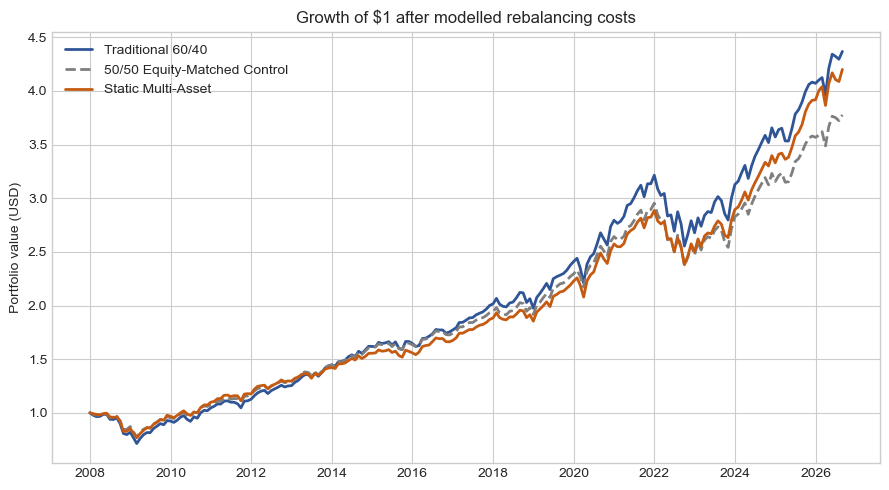

In [6]:
COLORS = {
    "Traditional 60/40": "#2F5597",
    "50/50 Equity-Matched Control": "#7F7F7F",
    "Static Multi-Asset": "#C55A11",
}
LINE_STYLES = {"50/50 Equity-Matched Control": "--"}
initial_date = portfolio_returns.index.min() - pd.offsets.MonthEnd(1)
wealth = pd.concat(
    [
        pd.DataFrame([np.ones(len(portfolio_returns.columns))], index=[initial_date], columns=portfolio_returns.columns),
        (1.0 + portfolio_returns).cumprod(),
    ]
)

fig, ax = plt.subplots(figsize=(9, 5))
for portfolio in wealth.columns:
    ax.plot(wealth.index, wealth[portfolio], label=portfolio, color=COLORS[portfolio], linestyle=LINE_STYLES.get(portfolio, "-"), linewidth=2)
ax.set_title("Growth of $1 after modelled rebalancing costs")
ax.set_ylabel("Portfolio value (USD)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "cumulative_returns.png", dpi=180, bbox_inches="tight")
plt.show()

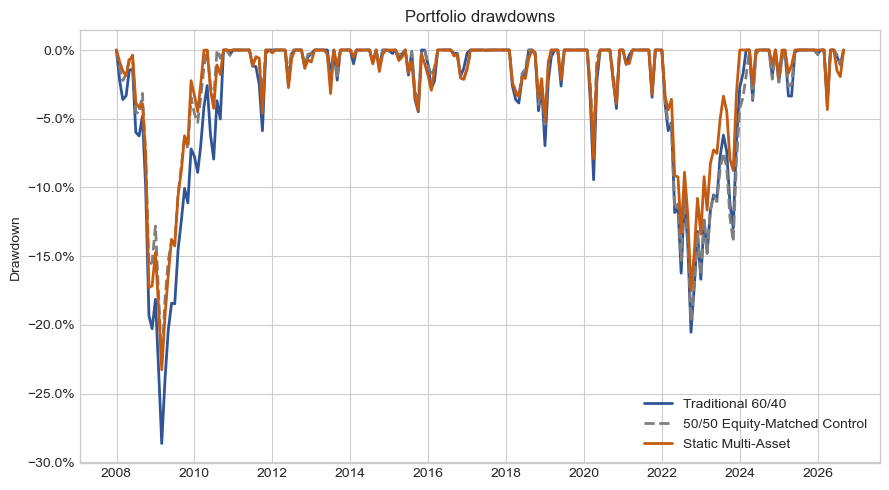

In [7]:
drawdowns = wealth / wealth.cummax() - 1.0
fig, ax = plt.subplots(figsize=(9, 5))
for portfolio in drawdowns.columns:
    ax.plot(drawdowns.index, drawdowns[portfolio], label=portfolio, color=COLORS[portfolio], linestyle=LINE_STYLES.get(portfolio, "-"), linewidth=2)
ax.set_title("Portfolio drawdowns")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "drawdowns.png", dpi=180, bbox_inches="tight")
plt.show()

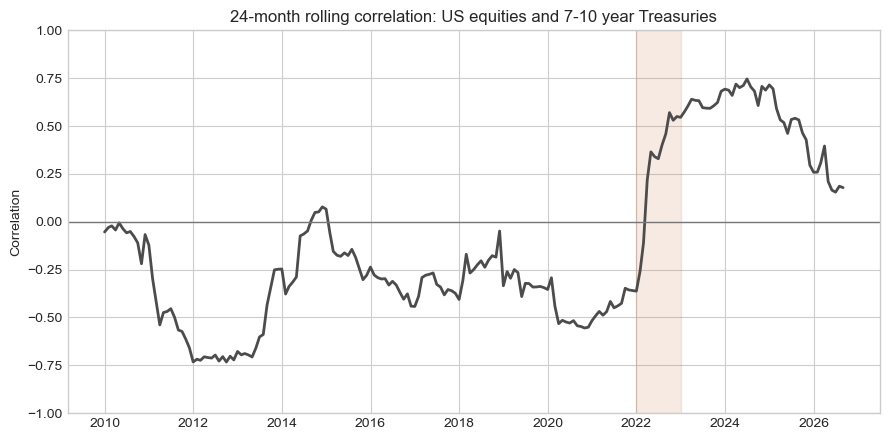

In [8]:
rolling_correlation = asset_returns["IVV"].rolling(24).corr(asset_returns["IEF"])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rolling_correlation.index, rolling_correlation, color="#4C4C4C", linewidth=2)
ax.axhline(0.0, color="#777777", linewidth=1)
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), color="#C55A11", alpha=0.12)
ax.set_title("24-month rolling correlation: US equities and 7-10 year Treasuries")
ax.set_ylabel("Correlation")
ax.set_ylim(-1.0, 1.0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "rolling_correlation.png", dpi=180, bbox_inches="tight")
plt.show()

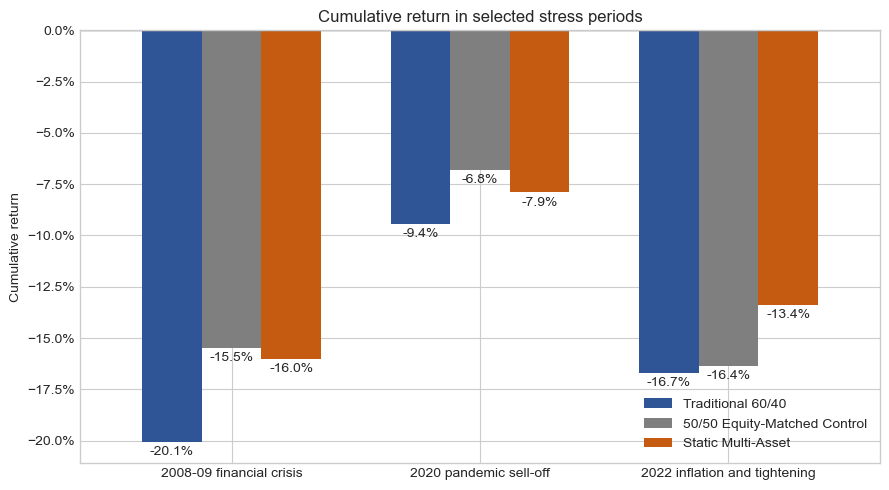

In [9]:
stress_plot = stress_table.loc[list(STRESS_WINDOWS.keys()), list(PORTFOLIO_WEIGHTS.keys())]
ax = stress_plot.plot(
    kind="bar",
    figsize=(9, 5),
    color=[COLORS[column] for column in stress_plot.columns],
    width=0.72,
)
ax.set_title("Cumulative return in selected stress periods")
ax.set_xlabel("")
ax.set_ylabel("Cumulative return")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.axhline(0.0, color="#777777", linewidth=1)
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.1%}" for value in container.datavalues], padding=3)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "stress_periods.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Interpretation and limitations

The comparison is a risk-return trade-off rather than a ranking of universally good and bad portfolios. The 50/50 control shows that reducing equity exposure explained part of the lower risk. The multi-asset portfolio then changed the mix of defensive assets: it was not the lowest-drawdown portfolio over the full sample, but it earned more than the 50/50 control and lost less in the 2022 inflation shock.

The common sample starts in 2008, uses US-dollar ETF returns and contains only a limited number of inflation shocks. The 50/50 control matches equity weight but not total volatility, duration or every risk exposure. The weights are illustrative, maximum drawdown is measured from month-end observations, and correlation does not establish macroeconomic causation. A UK investor would also need to consider sterling liabilities, global assets and currency hedging.